In [1]:
pip install polars elfen spacy

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.7 kB)
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
Using cached transformers-4.36.2-py3-none-any.whl (8.2 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-cp312-macosx_11_0_arm64.whl (2.4 MB)
  Attempting uninstall: Requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.

In [14]:
import polars as pl
from pathlib import Path

folder = Path("/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster")
csv_files = list(folder.glob("*.csv"))

dataframes = {}

for f in csv_files:
    key = f.stem.split("_")[0]
    print(f)
    print(key)
    dataframes[key] = pl.read_csv(f)

/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/QWEN_dataset_experiment_results.csv
QWEN
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/HuggingFaceTB_dataset_experiment_results.csv
HuggingFaceTB
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/mistralai_dataset_experiment_results.csv
mistralai
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/google_dataset_experiment_results.csv
google
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/meta-llama_dataset_experiment_results.csv
meta-llama


In [17]:
dataframes["QWEN"].head()

question_id,dataset_source,first_token_answer,unconstrained_text,parsed_text_answer,is_mismatch,top_1st_token_logprobs
str,str,str,str,str,bool,str
"""Q_0""","""OpinionQA""","""A""","""As an artificial intelligence …","""A""",false,"""{32: Logprob(logprob=-5.316593…"
"""Q_1""","""MMLU""","""C""","""The excerpt from Frederick Dou…","""C""",false,"""{34: Logprob(logprob=-0.000229…"
"""Q_2""","""MMLU""","""A""","""Bartering as a form of payment…","""Refusal/Unclear""",true,"""{32: Logprob(logprob=-0.027164…"
"""Q_3""","""MMLU""","""C""","""According to trials on diabete…","""C""",false,"""{34: Logprob(logprob=-0.000168…"
"""Q_4""","""OpinionQA""","""A""","""When considering whether medic…","""A""",false,"""{32: Logprob(logprob=-7.998623…"


In [19]:
!Python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.4 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [20]:
import elfen
from elfen import Extractor

# ----------------------------------------------------
# B. initializing Elfen
# ----------------------------------------------------
print("\nInitializing elfen feature extractor...")
extractor = Extractor(
    dataframes["QWEN"],
    language="en",
    backbone="spacy",
    text_column="unconstrained_text"
)

print("Extracting 1,061 linguistic features...")
extractor.extract_features()
df_features = extractor.get_data()


Initializing elfen feature extractor...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...


...

Extracting tree_branching...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:128: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting n_noun_chunks...
Extracting n_per_dependency_type...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena...
Extracting sichel_s...
Extractin

In [21]:
import polars as pl

# Iterate over columns and cast any remaining Object, List, or Struct columns to String
# This is a more robust way to ensure all complex/nested objects are converted to a string representation
for col in df_features.columns:
    if df_features[col].dtype in (pl.Object, pl.List, pl.Struct):
        df_features = df_features.with_columns(
            pl.col(col).map_elements(lambda x: str(x), return_dtype=pl.String)
        )

# Now Polars can safely write it to a CSV
df_features.write_csv("opinionqa_sample_features.csv")

Total Rows Analyzed: 900
Total Linguistic Features: 305
Overall Mismatch Rate: 46.33%


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]



--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
avg_word_length       -0.155526
cli                   -0.151472
lexical_density       -0.147538
avg_sd_aoa            -0.141986
avg_aoa               -0.139957
n_entities             0.135204
lix                   -0.133437
n_dependency_nummod    0.127909
rix                   -0.121209
n_num                  0.119026
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_52990/2426360637.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


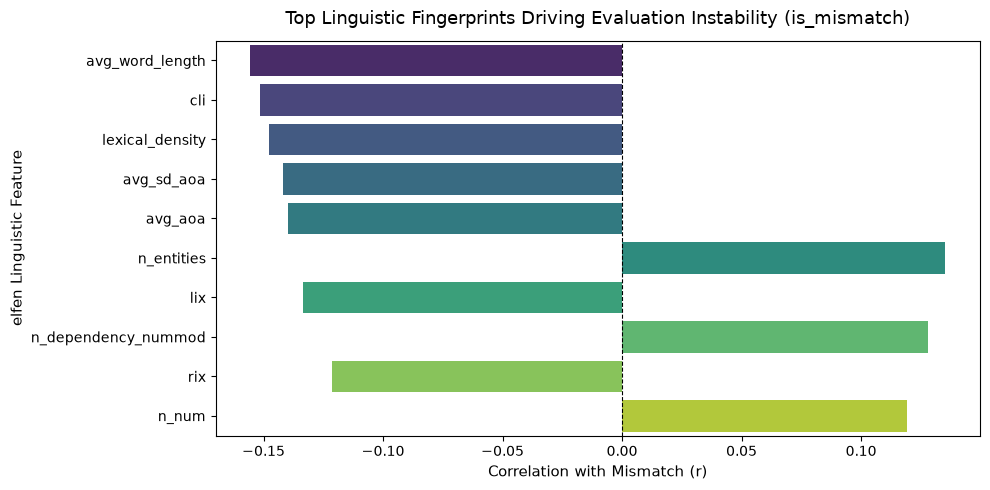

In [25]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the exported feature dataset
df = pl.read_csv("opinionqa_sample_features.csv")

# 2. Separate metadata columns from numeric linguistic features
metadata_cols = ["question_id", "first_token_answer", "unconstrained_text", "parsed_text_answer", "is_mismatch"]
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Total Rows Analyzed: {len(df)}")
print(f"Total Linguistic Features: {len(feature_cols)}")
print(f"Overall Mismatch Rate: {df['is_mismatch'].mean():.2%}")

# 3. Identify Top Distinguishing Linguistic Features (Matched vs. Mismatched)
df_pd = df.to_pandas()

# Convert boolean mismatch to integer for correlation
df_pd["mismatch_numeric"] = df_pd["is_mismatch"].astype(int)

# Filter strictly numeric feature columns
numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number]).columns

# Calculate correlation between linguistic features and mismatch occurrence
correlations = df_pd[numeric_features].apply(lambda x: x.corr(df_pd["mismatch_numeric"])).dropna()

# Sort top positively and negatively correlated features
top_features = correlations.abs().sort_values(ascending=False).head(10)
print("\n--- TOP 10 CORRELATED LINGUISTIC FEATURES ---")
print(correlations[top_features.index])

# 4. Generate Poster Visual: Top Feature Importance Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Top Linguistic Fingerprints Driving Evaluation Instability (is_mismatch)", fontsize=13, pad=12)
plt.xlabel("Correlation with Mismatch (r)", fontsize=11)
plt.ylabel("elfen Linguistic Feature", fontsize=11)
plt.tight_layout()
plt.savefig("feature_importance_poster.png", dpi=300)
plt.show()

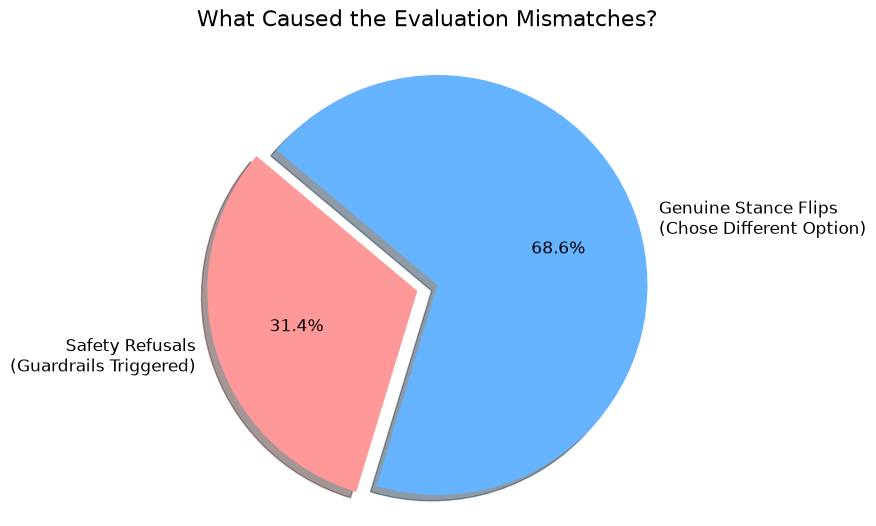

Total Mismatches Analyzed: 417
Mismatches due to Safety Refusals: 131
Mismatches due to Stance Flips: 286


In [26]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Filter the dataset to ONLY include rows where an evaluation mismatch occurred
mismatched_df = df.filter(pl.col("is_mismatch") == True)

# 2. Count the types of mismatches
# "Refusals" are cases where the regex parser couldn't find a valid A/B/C/D answer
# "Stance Flips" are cases where the model picked a valid option, but it was DIFFERENT from the first token
refusals_count = mismatched_df.filter(pl.col("parsed_text_answer") == "Refusal/Unclear").height
stance_flips_count = mismatched_df.filter(pl.col("parsed_text_answer") != "Refusal/Unclear").height

# 3. Prepare data for the pie chart
labels = ['Safety Refusals\n(Guardrails Triggered)', 'Genuine Stance Flips\n(Chose Different Option)']
sizes = [refusals_count, stance_flips_count]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # slightly separate the Refusals slice for visual emphasis

# 4. Generate the Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12})

plt.title('What Caused the Evaluation Mismatches?', fontsize=16, pad=20)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle

# 5. Save and Display
plt.savefig("refusal_breakdown_pie_chart.png", dpi=300, bbox_inches='tight')
plt.show()

# Print the raw numbers for your records
print(f"Total Mismatches Analyzed: {len(mismatched_df)}")
print(f"Mismatches due to Safety Refusals: {refusals_count}")
print(f"Mismatches due to Stance Flips: {stance_flips_count}")

Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


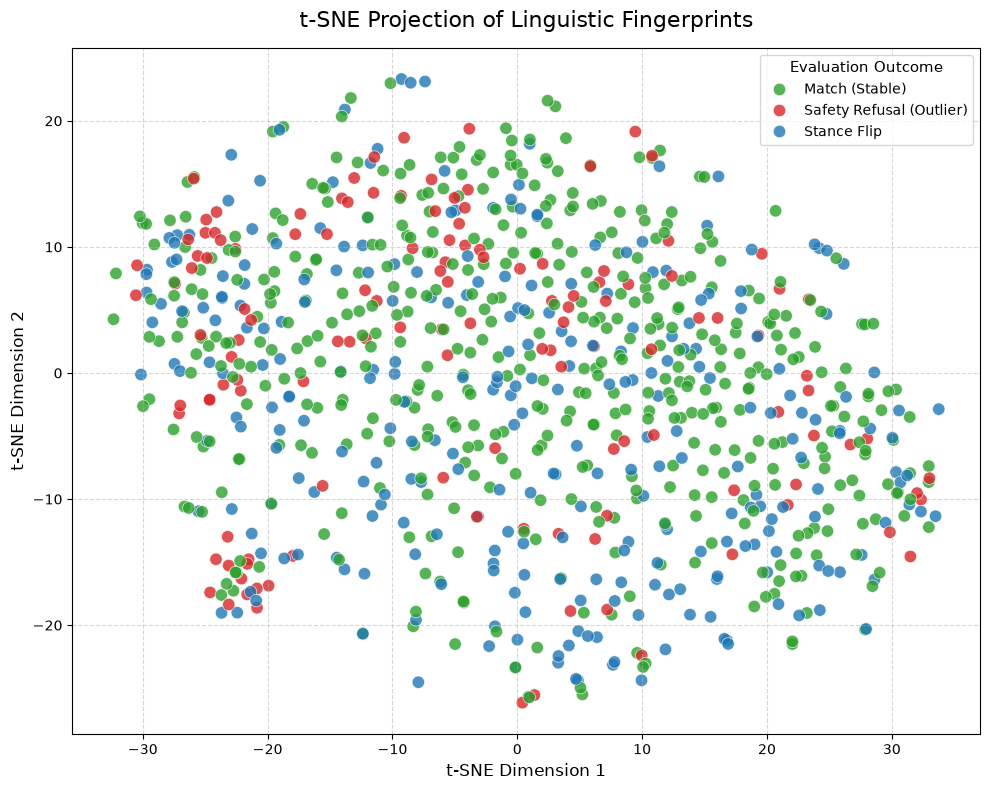

In [31]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("Preparing data for t-SNE...")
# 1. Convert to Pandas for scikit-learn compatibility
df_pd = df.to_pandas()

# 2. Create a specific labeling column to color our clusters
def categorize_response(row):
    if row['is_mismatch'] == False:
        return 'Match (Stable)'
    elif row['parsed_text_answer'] == 'Refusal/Unclear':
        return 'Safety Refusal (Outlier)'
    else:
        return 'Stance Flip'

df_pd['Response_Category'] = df_pd.apply(categorize_response, axis=1)

# 3. Isolate strictly numeric linguistic features
metadata_cols = [
    "question_id", "first_token_answer", "unconstrained_text",
    "parsed_text_answer", "is_mismatch", "Response_Category"
]
feature_cols = [col for col in df_pd.columns if col not in metadata_cols]
numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])

# Replace inf/-inf with NaN, then fill all NaN (including former infs) with 0
numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
numeric_features = numeric_features.fillna(0)

print("Scaling features...")
# 4. Standardize the data (t-SNE is highly sensitive to differing scales)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

print("Running t-SNE projection (this may take a moment)...")
# 5. Run the t-SNE algorithm
# Note: perplexity must be less than the number of samples.
# We use a dynamic calculation to prevent errors on small sample sizes.
perplexity_value = min(30, len(df_pd) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
tsne_results = tsne.fit_transform(scaled_features)

# Attach results back to the DataFrame
df_pd['tsne_1'] = tsne_results[:, 0]
df_pd['tsne_2'] = tsne_results[:, 1]

print("Plotting the clusters...")
# 6. Generate the Scatter Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='Response_Category',
    palette={'Match (Stable)': '#2ca02c', 'Stance Flip': '#1f77b4', 'Safety Refusal (Outlier)': '#d62728'},
    data=df_pd,
    alpha=0.8,
    s=80,
    edgecolor='w',
    linewidth=0.5
)

plt.title('t-SNE Projection of Linguistic Fingerprints', fontsize=16, pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Evaluation Outcome', title_fontsize='11', fontsize='10', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("tsne_linguistic_clusters.png", dpi=300)
plt.show()